# Customer Churn Prediction & Retention Analytics System

## Day 1 — Data Understanding

### Project Objective

Build an end-to-end customer churn prediction and retention analytics system that identifies customers at risk of churn, explains the major drivers of churn, estimates customer risk, and supports data-driven retention strategies.

### Business Problem

Customer churn directly affects revenue, customer lifetime value, and business growth. The objective of this project is to analyze customer behavior and develop a machine learning system capable of predicting customers who are likely to churn.

### Key Questions

1. What proportion of customers are churning?
2. Which customer characteristics are associated with churn?
3. Which services and contract types have higher churn?
4. Which customers are at the highest risk of churn?
5. What factors contribute most to churn?
6. How can the business prioritize retention efforts?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## Project Paths

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS = PROJECT_ROOT / "models"
REPORTS = PROJECT_ROOT / "reports"

print("Project root:", PROJECT_ROOT)
print("Raw data:", DATA_RAW)
print("Processed data:", DATA_PROCESSED)

Project root: C:\Users\balle\customer-churn-prediction-retention-analytics
Raw data: C:\Users\balle\customer-churn-prediction-retention-analytics\data\raw
Processed data: C:\Users\balle\customer-churn-prediction-retention-analytics\data\processed


## Load Raw Dataset

In [3]:
file_path = DATA_RAW / "bank_customer_churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df.describe(include="object").T

,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


In [10]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing["missing_percentage"] = (
    missing["missing_count"] / len(df) * 100
)

missing

,missing_count,missing_percentage
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


In [11]:
duplicated_count=df.duplicated().sum()
print(duplicated_count)

0


In [12]:
df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [13]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

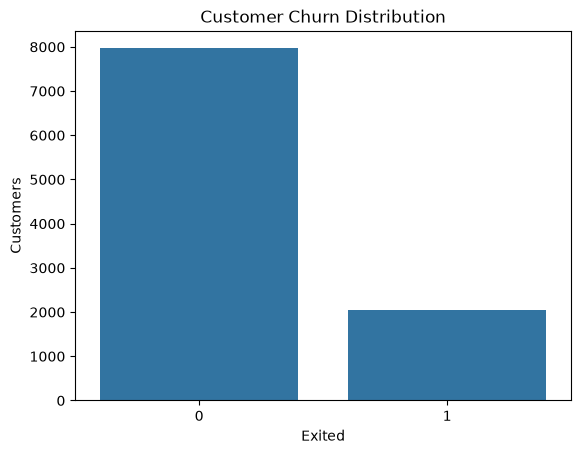

In [14]:
sns.countplot(data=df,x='Exited')
plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Customers")
plt.show()

## Calculate churn rate

In [45]:
churn_rate=df['Exited'].mean()*100
print("churn rate is: ",churn_rate)

churn rate is:  20.369999999999997


## Data quality

In [16]:
data_quality = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "missing_values": df.isnull().sum().values,
    "missing_percentage": (
        df.isnull().sum().values / len(df) * 100
    ),
    "unique_values": df.nunique().values
})

data_quality

,column,data_type,missing_values,missing_percentage,unique_values
0,RowNumber,int64,0,0.0,10000
1,CustomerId,int64,0,0.0,10000
2,Surname,str,0,0.0,2932
3,CreditScore,int64,0,0.0,460
4,Geography,str,0,0.0,3
5,Gender,str,0,0.0,2
6,Age,int64,0,0.0,70
7,Tenure,int64,0,0.0,11
8,Balance,float64,0,0.0,6382
9,NumOfProducts,int64,0,0.0,4


In [17]:
data_quality.to_csv(
    DATA_PROCESSED / "data_quality_summary.csv",
    index=False
)

print("Data quality summary saved.")

Data quality summary saved.


## Initial Data Dictionary

| Column | Description | Initial Role |
|---|---|---|
| RowNumber | Record number assigned to the customer | Identifier |
| CustomerId | Unique customer identifier | Identifier |
| Surname | Customer surname | Customer attribute |
| CreditScore | Customer credit score | Feature |
| Geography | Customer geographic location | Feature |
| Gender | Customer gender | Feature |
| Age | Customer age | Feature |
| Tenure | Number of years the customer has been with the bank | Feature |
| Balance | Customer account balance | Feature |
| NumOfProducts | Number of bank products used by the customer | Feature |
| HasCrCard | Whether the customer has a credit card | Feature |
| IsActiveMember | Whether the customer is an active member | Feature |
| EstimatedSalary | Estimated customer salary | Feature |
| Exited | Whether the customer left the bank | Target |

## Exploratory Churn Analysis

This section examines customer churn across demographic, geographic, behavioral, banking relationship, and financial characteristics.

The objective is to identify early patterns that can guide feature engineering, machine learning, and retention strategies.

In [18]:
def churn_summary(data, column):
    summary = (
        data.groupby(column)["Exited"]
        .agg(
            customers="count",
            churned="sum",
            churn_rate="mean"
        )
        .reset_index()
    )
    
    summary["churn_rate"] = (summary["churn_rate"] * 100).round(2)
    
    return summary.sort_values("churn_rate", ascending=False)

### Churn by Geography

Geographic differences can reveal whether customer retention varies across the bank's operating markets.

In [19]:
geo_churn = churn_summary(df, "Geography")

geo_churn

,Geography,customers,churned,churn_rate
1,Germany,2509,814,32.44
2,Spain,2477,413,16.67
0,France,5014,810,16.15


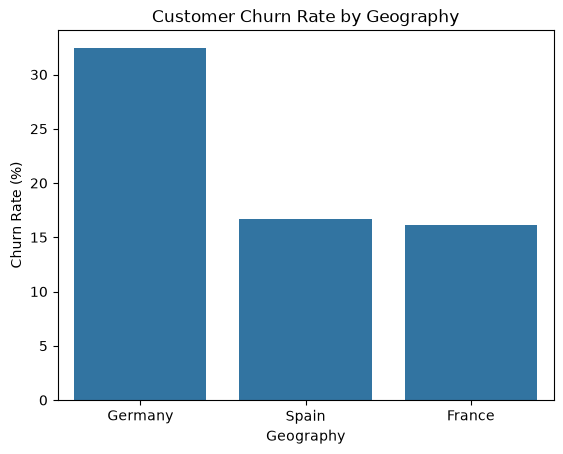

In [20]:
sns.barplot(data=geo_churn,
            x="Geography",
            y="churn_rate")
plt.title("Customer Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

plt.show()

### Churn by Gender

This analysis compares customer churn rates across gender groups to determine whether there are meaningful differences in retention.

In [21]:
gender_churn = churn_summary(df, "Gender")

gender_churn

,Gender,customers,churned,churn_rate
0,Female,4543,1139,25.07
1,Male,5457,898,16.46


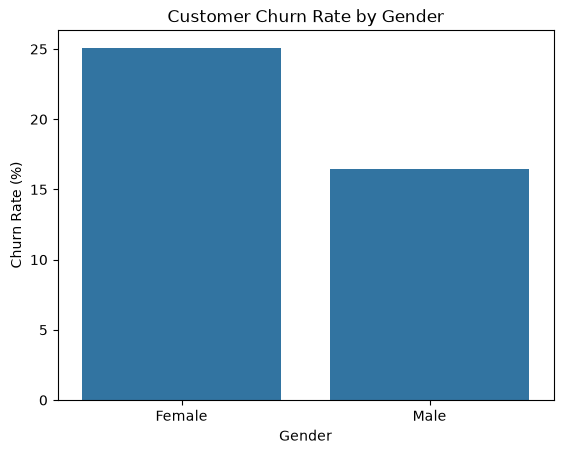

In [22]:
sns.barplot(data=gender_churn,
            x="Gender",
            y="churn_rate")

plt.title("Customer Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

### Churn by Age Group

Customer age may influence retention behavior. Age groups are created to identify broader customer segments with different churn patterns.

In [23]:
age_bins = [17, 25, 35, 45, 55, 65, 100]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)



In [24]:
age_churn = churn_summary(df, "AgeGroup")

age_churn

,AgeGroup,customers,churned,churn_rate
3,46-55,1311,663,50.57
4,56-65,536,259,48.32
2,36-45,3736,733,19.62
5,66+,264,35,13.26
1,26-35,3542,301,8.50
0,18-25,611,46,7.53


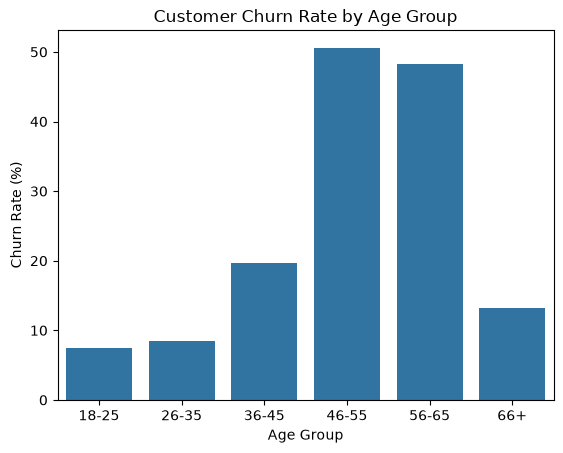

In [25]:
sns.barplot(
    data=age_churn,
    x="AgeGroup",
    y="churn_rate",
    order=age_labels
)

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

### Churn by Tenure

This analysis examines whether customer retention varies according to the length of the customer's relationship with the bank.

In [26]:
tenure_bins = [-1, 2, 5, 8, 10]

tenure_labels = [
    "0-2 years",
    "3-5 years",
    "6-8 years",
    "9-10 years"
]

df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)



In [27]:
tenure_churn = churn_summary(df, "TenureGroup")

tenure_churn

,TenureGroup,customers,churned,churn_rate
3,9-10 years,1474,314,21.30
0,0-2 years,2496,528,21.15
1,3-5 years,3010,625,20.76
2,6-8 years,3020,570,18.87


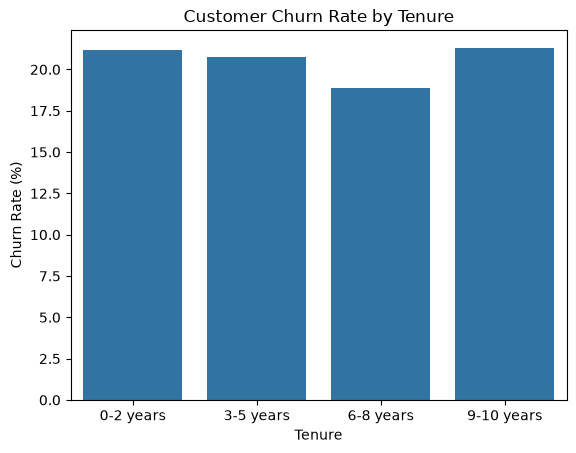

In [28]:
sns.barplot(
    data=tenure_churn,
    x="TenureGroup",
    y="churn_rate",
    order=tenure_labels
)

plt.title("Customer Churn Rate by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")

plt.show()

### Churn by Customer Activity

Active membership may indicate stronger engagement with the bank. This analysis compares churn rates between active and inactive customers.

In [29]:
df["ActivityStatus"] = df["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})


In [30]:
activity_churn = churn_summary(df, "ActivityStatus")

activity_churn

,ActivityStatus,customers,churned,churn_rate
1,Inactive,4849,1302,26.85
0,Active,5151,735,14.27


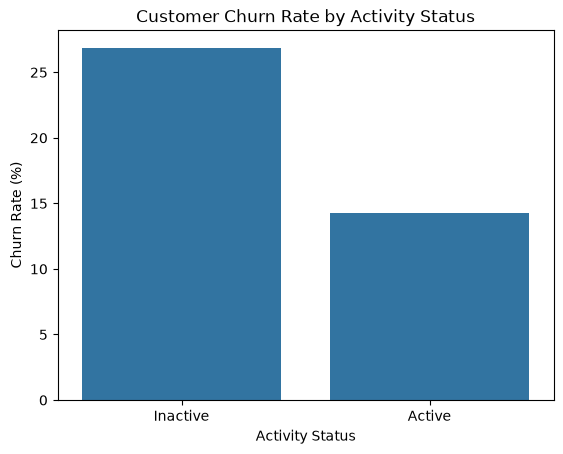

In [31]:
sns.barplot(
    data=activity_churn,
    x="ActivityStatus",
    y="churn_rate"
)

plt.title("Customer Churn Rate by Activity Status")
plt.xlabel("Activity Status")
plt.ylabel("Churn Rate (%)")

plt.show()

### Churn by Number of Banking Products

The number of products used by a customer may indicate the depth of the customer's relationship with the bank.

In [32]:
product_churn = churn_summary(df, "NumOfProducts")

product_churn

,NumOfProducts,customers,churned,churn_rate
3,4,60,60,100.00
2,3,266,220,82.71
0,1,5084,1409,27.71
1,2,4590,348,7.58


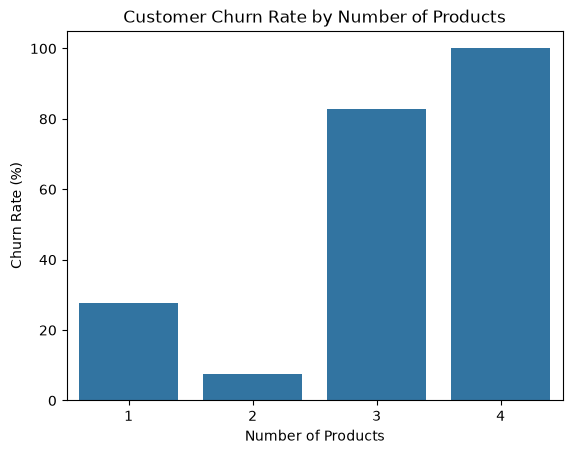

In [33]:
sns.barplot(
    data=product_churn,
    x="NumOfProducts",
    y="churn_rate"
)

plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

### Churn by Credit Card Ownership

This analysis examines whether credit card ownership is associated with customer retention.

In [34]:
df["CreditCardStatus"] = df["HasCrCard"].map({
    0: "No Credit Card",
    1: "Has Credit Card"
})



In [35]:
credit_card_churn = churn_summary(df, "CreditCardStatus")

credit_card_churn

,CreditCardStatus,customers,churned,churn_rate
1,No Credit Card,2945,613,20.81
0,Has Credit Card,7055,1424,20.18


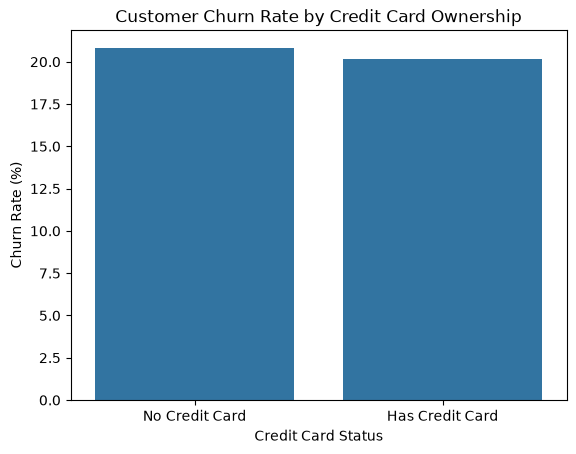

In [36]:
sns.barplot(
    data=credit_card_churn,
    x="CreditCardStatus",
    y="churn_rate"
)

plt.title("Customer Churn Rate by Credit Card Ownership")
plt.xlabel("Credit Card Status")
plt.ylabel("Churn Rate (%)")

plt.show()

### Churn by Account Balance

Account balance may provide insight into customer value and relationship characteristics. Balance groups are used to compare churn rates across different balance ranges.

In [37]:
balance_bins = [-1, 0, 50000, 100000, 150000, np.inf]

balance_labels = [
    "Zero",
    "1-50K",
    "50K-100K",
    "100K-150K",
    "150K+"
]

df["BalanceGroup"] = pd.cut(
    df["Balance"],
    bins=balance_bins,
    labels=balance_labels
)


In [38]:

balance_churn = churn_summary(df, "BalanceGroup")

balance_churn

,BalanceGroup,customers,churned,churn_rate
1,1-50K,75,26,34.67
3,100K-150K,3830,987,25.77
4,150K+,969,224,23.12
2,50K-100K,1509,300,19.88
0,Zero,3617,500,13.82


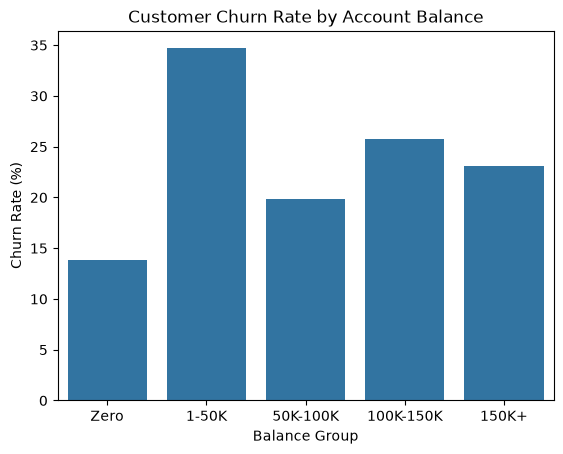

In [39]:
sns.barplot(
    data=balance_churn,
    x="BalanceGroup",
    y="churn_rate",
    order=balance_labels
)

plt.title("Customer Churn Rate by Account Balance")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [40]:
overall_churn_rate = df["Exited"].mean() * 100

print(f"Overall churn rate: {overall_churn_rate:.2f}%")

Overall churn rate: 20.37%


In [41]:
initial_churn_analysis = {
    "geography": geo_churn,
    "gender": gender_churn,
    "age_group": age_churn,
    "tenure_group": tenure_churn,
    "activity": activity_churn,
    "products": product_churn,
    "credit_card": credit_card_churn,
    "balance_group": balance_churn
}

In [42]:
geo_churn.to_csv(DATA_PROCESSED / "churn_by_geography.csv", index=False)
gender_churn.to_csv(DATA_PROCESSED / "churn_by_gender.csv", index=False)
age_churn.to_csv(DATA_PROCESSED / "churn_by_age_group.csv", index=False)
tenure_churn.to_csv(DATA_PROCESSED / "churn_by_tenure.csv", index=False)
activity_churn.to_csv(DATA_PROCESSED / "churn_by_activity.csv", index=False)
product_churn.to_csv(DATA_PROCESSED / "churn_by_products.csv", index=False)
credit_card_churn.to_csv(DATA_PROCESSED / "churn_by_credit_card.csv", index=False)
balance_churn.to_csv(DATA_PROCESSED / "churn_by_balance.csv", index=False)

print("Initial churn analysis results saved successfully.")

Initial churn analysis results saved successfully.


## Initial Business Insights

### Key Findings

1. **Geography:** Germany has the highest observed churn rate at 32.44%, substantially above the overall churn rate of 20.37%.

2. **Gender:** Female customers have a higher observed churn rate (25.07%) than male customers (16.46%).

3. **Age:** Customers aged 46–55 and 56–65 show exceptionally high churn rates of 50.57% and 48.32%, respectively.

4. **Tenure:** Churn rates vary relatively little across tenure groups, ranging from 18.87% to 21.30%.

5. **Customer Activity:** Inactive customers have a churn rate of 26.85%, compared with 14.27% among active customers, indicating a strong association between customer activity and retention.

6. **Number of Products:** Customers with three or four products exhibit unusually high churn rates. However, these groups are relatively small, so this pattern requires further investigation before drawing broad business conclusions.

7. **Credit Card Ownership:** Customers with and without credit cards have similar churn rates (20.18% vs. 20.81%), suggesting limited standalone association.

8. **Account Balance:** Customers with positive balances generally show higher churn than zero-balance customers, with the 100K–150K segment showing a churn rate of 25.77%.

### Important Caveat

These findings represent associations observed in historical customer-level data. They do not establish causal relationships. Further statistical analysis and machine learning will be used to evaluate whether these variables provide meaningful predictive information.

## Product Count Anomaly Investigation

Customers with three or four products show exceptionally high observed churn rates. Because these groups contain relatively few customers, their results require further investigation before being treated as generalizable business patterns.

In [46]:
product_detail = (
    df.groupby(["NumOfProducts", "Exited"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={
          0: "Stayed",
          1: "Exited"
      })
)

product_detail

Exited,Stayed,Exited
NumOfProducts,,
1,3675,1409
2,4242,348
3,46,220
4,0,60


In [47]:
product_detail["Total"] = (
    product_detail["Stayed"] + product_detail["Exited"]
)

product_detail["Churn_Rate"] = (
    product_detail["Exited"] / product_detail["Total"] * 100
).round(2)

product_detail

Exited,Stayed,Exited,Total,Churn_Rate
NumOfProducts,,,,
1,3675,1409,5084,27.71
2,4242,348,4590,7.58
3,46,220,266,82.71
4,0,60,60,100.00


In [48]:
product_profile = (
    df.groupby("NumOfProducts")
      .agg(
          customers=("CustomerId", "count"),
          avg_age=("Age", "mean"),
          avg_balance=("Balance", "mean"),
          avg_credit_score=("CreditScore", "mean"),
          avg_salary=("EstimatedSalary", "mean"),
          active_rate=("IsActiveMember", "mean")
      )
      .round(2)
)

product_profile

,customers,avg_age,avg_balance,avg_credit_score,avg_salary,active_rate
NumOfProducts,,,,,,
1,5084,39.67,98551.87,649.12,99487.26,0.50
2,4590,37.75,51879.15,652.19,100452.01,0.53
3,266,43.20,75458.33,648.11,104318.13,0.42
4,60,45.68,93733.14,653.58,104763.72,0.48


In [49]:
df[df["NumOfProducts"] >= 3][
    [
        "CustomerId",
        "Geography",
        "Gender",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "HasCrCard",
        "IsActiveMember",
        "EstimatedSalary",
        "Exited"
    ]
].head(20)

,CustomerId,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2,15619304,France,Female,42,8,159660.80,3,1,0,113931.57,1
7,15656148,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
30,15589475,Spain,Female,39,3,0.00,3,1,0,140469.38,1
70,15703793,Germany,Male,58,2,133745.44,4,1,0,28373.86,1
88,15622897,France,Female,46,4,0.00,3,1,0,93251.42,1
90,15757535,Spain,Female,44,5,0.00,3,1,1,174205.22,1
227,15676895,Germany,Female,39,6,74596.15,3,1,1,85746.52,1
237,15764866,Germany,Female,43,3,116220.50,3,1,0,55803.96,1
238,15794056,France,Female,46,2,0.00,3,1,0,89048.46,1
271,15619955,Germany,Male,34,3,100337.96,3,1,0,48559.19,1


In [50]:
df[df["NumOfProducts"] >= 3]["Exited"].value_counts()

Exited
1    280
0     46
Name: count, dtype: int64

In [51]:
day1_summary = pd.DataFrame({
    "Analysis": [
        "Geography",
        "Gender",
        "Age Group",
        "Tenure Group",
        "Activity Status",
        "Number of Products",
        "Credit Card",
        "Balance Group"
    ],
    "Highest_Risk_Segment": [
        geo_churn.iloc[0]["Geography"],
        gender_churn.iloc[0]["Gender"],
        age_churn.iloc[0]["AgeGroup"],
        tenure_churn.iloc[0]["TenureGroup"],
        activity_churn.iloc[0]["ActivityStatus"],
        product_churn.iloc[0]["NumOfProducts"],
        credit_card_churn.iloc[0]["CreditCardStatus"],
        balance_churn.iloc[0]["BalanceGroup"]
    ],
    "Highest_Churn_Rate": [
        geo_churn.iloc[0]["churn_rate"],
        gender_churn.iloc[0]["churn_rate"],
        age_churn.iloc[0]["churn_rate"],
        tenure_churn.iloc[0]["churn_rate"],
        activity_churn.iloc[0]["churn_rate"],
        product_churn.iloc[0]["churn_rate"],
        credit_card_churn.iloc[0]["churn_rate"],
        balance_churn.iloc[0]["churn_rate"]
    ]
})

day1_summary

,Analysis,Highest_Risk_Segment,Highest_Churn_Rate
0,Geography,Germany,32.44
1,Gender,Female,25.07
2,Age Group,46-55,50.57
3,Tenure Group,9-10 years,21.30
4,Activity Status,Inactive,26.85
5,Number of Products,4.0,100.00
6,Credit Card,No Credit Card,20.81
7,Balance Group,1-50K,34.67


In [52]:
day1_summary.to_csv(
    DATA_PROCESSED / "day1_churn_summary.csv",
    index=False
)

print("Day 1 summary saved successfully.")

Day 1 summary saved successfully.


## Day 1 — Conclusion

The initial analysis shows that customer churn is not evenly distributed across the customer base.

The strongest observed differences are associated with age, customer activity, geography, gender, number of banking products, and account balance.

Customers aged 46–65 show particularly high observed churn rates, while inactive customers have substantially higher churn than active customers. Germany also shows a materially higher churn rate than France and Spain.

The number-of-products analysis revealed an unusual pattern among customers with three or four products. Because these groups are relatively small, this relationship will be investigated further before being used for business recommendations.

Tenure and credit card ownership show comparatively smaller differences in observed churn rates.

These findings provide an initial understanding of customer churn patterns and will guide the data-cleaning, feature-engineering, statistical analysis, and machine-learning stages of the project.

### Key Analytical Principle

Observed associations should not be interpreted as causal relationships. The next stages of the project will evaluate whether these variables provide meaningful predictive information when considered jointly.

### Product Count Anomaly — Interpretation

Customers with three and four banking products exhibit exceptionally high observed churn rates of 82.71% and 100%, respectively. However, these groups contain only 266 and 60 customers.

A comparison of basic customer characteristics shows that these groups do not have dramatically different average credit scores or estimated salaries. Customers with three products are somewhat older and have a lower active-member rate than customers with one or two products, but these differences alone do not explain the extremely high observed churn.

Therefore, the relationship between product count and churn should be treated as an unusual dataset pattern requiring further investigation rather than as evidence of a causal relationship.

The observations will be retained for subsequent exploratory analysis and machine learning.

# Day 1 — Final Conclusion

The initial data understanding and churn analysis established a clear foundation for the project.

The dataset contains 10,000 customer records and 14 variables, with no missing values and no duplicate rows. The target variable, `Exited`, indicates whether a customer left the bank, with an overall observed churn rate of 20.37%.

Initial analysis identified several important patterns:

- Germany has a substantially higher churn rate than France and Spain.
- Female customers have a higher observed churn rate than male customers.
- Customers aged 46–65 show particularly high churn rates.
- Inactive customers have substantially higher churn than active customers.
- Customers with one product have considerably higher churn than customers with two products.
- Customers with three and four products exhibit exceptionally high churn rates, but these groups are relatively small and require further investigation.
- Credit card ownership shows very little difference in observed churn.
- Tenure also shows relatively limited variation in churn across the defined groups.
- Customers with positive account balances generally show higher churn than customers with zero balances.

These findings represent associations in historical customer-level data and should not be interpreted as causal relationships.

The next stage will focus on deeper exploratory data analysis, data-quality validation, feature relationships, outlier investigation, and preparation of a clean analytical dataset for machine learning.